In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/karimchibani/donner-bruit/donnees_seir_bruitees.csv


In [15]:
df=pd.read_csv("/kaggle/input/datasets/karimchibani/donner-bruit/donnees_seir_bruitees.csv")

In [8]:
df.head()

,Temps_Jours,Infectes_Bruites
0,0.000000,45.099211
1,2.068966,66.726861
2,4.137931,74.801997
3,6.206897,62.666547
4,8.275862,47.189487


In [6]:
df.shape

(30, 2)


Lancement du MCMC (Metropolis-Hastings)...


Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [beta]
>Metropolis: [sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics



--- RÉSULTATS DE L'ESTIMATION MCMC ---
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.008  0.001   0.008    0.009      0.000    0.000     676.0     570.0   
sigma  4.649  0.662   3.532    5.847      0.027    0.024     596.0     551.0   

       r_hat  
beta     1.0  
sigma    1.0  


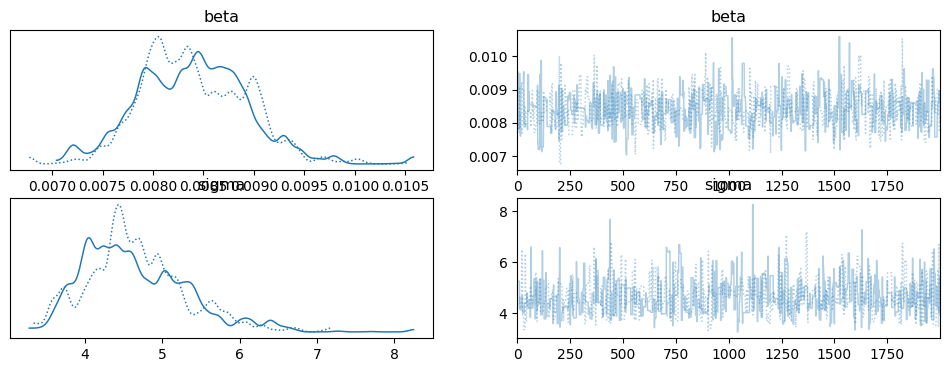

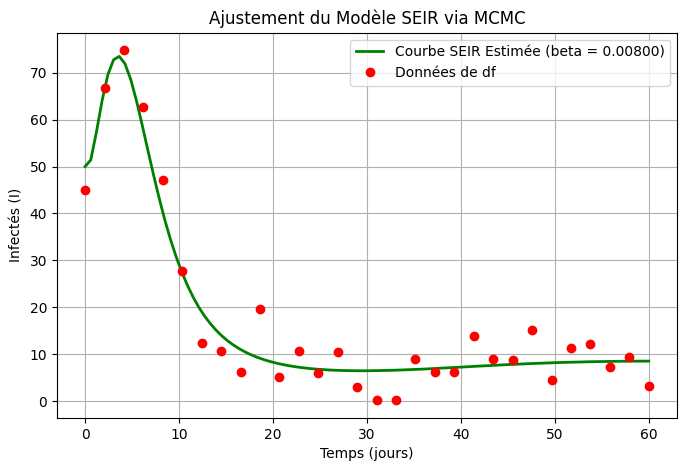

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from pytensor.compile.ops import wrap_py
from scipy.integrate import solve_ivp
import warnings
warnings.filterwarnings("ignore")

# =====================================================================
# PARAMÈTRES FIXES DU MODÈLE SEIR
# =====================================================================
Lambda = 10
alpha = 0.5
gamma = 0.3
mu = 0.1
X0 = [200.0, 30.0, 50.0, 10.0]

# Raccourcis directs vers tes colonnes de 'df' déjà existant
t_data = df['Temps_Jours'].values        
I_bruite = df['Infectes_Bruites'].values      

# =====================================================================
# ENCAPSULATION NUMÉRIQUE DE L'ODE SEIR
# =====================================================================
def seir_ode(t, X, beta):
    S, E, I, R = X
    dSdt = Lambda - beta * S * I - mu * S
    dEdt = beta * S * I - (mu + alpha) * E
    dIdt = alpha * E - (mu + gamma) * I
    dRdt = gamma * I - mu * R
    return [dSdt, dEdt, dIdt, dRdt]

@wrap_py(itypes=[pt.dscalar], otypes=[pt.dvector])
def obtenir_I_pure_op(beta_val):
    beta_float = float(beta_val)
    sol = solve_ivp(seir_ode, [t_data[0], t_data[-1]], X0, args=(beta_float,), t_eval=t_data, method='RK45')
    return sol.y[2]

# =====================================================================
# LE MODÈLE MCMC BAYÉSIEN (PyMC)
# =====================================================================
with pm.Model() as modele_bayesian:
    
    # Lois a priori (Priors)
    beta = pm.Uniform('beta', lower=0.0001, upper=0.02)
    sigma = pm.HalfNormal('sigma', sigma=15.0)
    
    # Correspondance avec l'opérateur ODE
    I_theorique = obtenir_I_pure_op(beta)
    
    # Vraisemblance (Likelihood)
    Y_obs = pm.Normal('Y_obs', mu=I_theorique, sigma=sigma, observed=I_bruite)
    
    # Échantillonnage MCMC (Algorithme de Metropolis-Hastings)
    print("\nLancement du MCMC (Metropolis-Hastings)...")
    trace = pm.sample(draws=2000, tune=1000, chains=2, step=pm.Metropolis(), return_inferencedata=True)

# =====================================================================
# EXPLOITATION DES RÉSULTATS ET GRAPHIQUES
# =====================================================================
print("\n--- RÉSULTATS DE L'ESTIMATION MCMC ---")
print(az.summary(trace, var_names=['beta', 'sigma']))

# Graphique 1 : Diagnostic des chaînes MCMC
az.plot_trace(trace, var_names=['beta', 'sigma'])

# Extraction de la moyenne de beta pour le tracé final
beta_estime = az.summary(trace, var_names=['beta'])['mean'].values[0]
t_courbe = np.linspace(t_data[0], t_data[-1], 100)
sol_finale = solve_ivp(seir_ode, [t_data[0], t_data[-1]], X0, args=(beta_estime,), t_eval=t_courbe)

# Graphique 2 : Ajustement de la courbe estimée sur tes données
plt.figure(figsize=(8, 5), facecolor='white')
plt.plot(t_courbe, sol_finale.y[2], 'g-', linewidth=2, label=f'Courbe SEIR Estimée (beta = {beta_estime:.5f})')
plt.plot(t_data, I_bruite, 'ro', label='Données de df')
plt.xlabel('Temps (jours)')
plt.ylabel('Infectés (I)')
plt.title('Ajustement du Modèle SEIR via MCMC')
plt.legend()
plt.grid(True)
plt.show()

"À partir du tableau des résultats statistiques de l'estimateur MCMC, on extrait directement les valeurs moyennes a posteriori (Mean) ainsi que leurs intervalles de crédibilité (HDI 94%) :Le taux de transmission estimé est $\beta = 0.008$ avec un intervalle $HDI_{94\%} = [0.008, 0.009]$.L'écart-type du bruit sur les données est $\sigma = 4.649$ avec un intervalle $HDI_{94\%} = [3.532, 5.847]$